# Week 10 - 피처 엔지니어링 및 모델 해석
**빅데이터 응용 실습 | Feature Importance, SHAP, LIME**

- 성능 중심의 맹심 -> 설명 가능한 모델

### 우리의 현주소
- 다양한 모델 학습(Random Forest, XGBoost 등)
- 하이퍼파라미터 튜닝을 통한 정확도(Accuracy) 극대화
- 교차검증으로 성능 입증 완료

### 현업의 필수 질문
- 이 데이터에서 가장 결정적인 역할을 한 변수는 무엇인가?
- 특정 샘플을 '긍정(1)'으로 분류한 근거는 무엇인가?
- 이 결과를 비전문가(고객, 경영잔)에게 납득시킬 수 있는가?

**설명 가능성이 결여된 뛰어난 성능은 실무에서 결코 신뢰를 얻을 수 없음**

---

## Feature engenering

**원본 데이터를 기계가 학습하기 좋고, 인간이 이해하기 쉬운 형태로 변환하는 과정**
- Raw Data -> Feature Engenering -> Model & Insight

**정제된 피처는 모델의 성능을 극대화 할 뿐만 아니라, 향후 도출될 변수의 중요도의 직관적 해석을 가능하게 함**


---


## Feature Importance로 모델 전체를 지배하는 핵심 변수 찾기
- 불순도 감소 기반 중요도

### 핵심 질문: 이 모델에서 어떤 변수가 예측에 가장 큰 영향을 주었는가? (Global View)

### 작동 원리 (트리 모델 기준)
* 특정 변수가 트리의 분기(Split)에서 자주 사용될수록 중요도가 상승.
* 분기 후 클래스의 불순도(Information Gain, Gini)를 얼마나 크게 감소시켰는지 측정.

### 장점 및 한계
* **[+]** 계산이 매우 빠르고 직관적인 전역적(Global) 해석 제공.
* **[-]** 연속형 변수에 유리하며, 상관관계가 높은 변수들 간에 중요도가 분산되는 취약점 존재.
---

## 순열 중요도 (Permutation Importance)
- 데이터의 배열을 무너뜨려 변수의 진짜 가치를 증명

### 변수 중요도 측정 원리 (Permutation Importance)

과정은 크게 3단계로 이루어집니다:

1. **정상 데이터**
   * **기준 성능 (Base Performance):** 원본 데이터로 모델의 기본 성능을 측정합니다. (마치 젠가 탑이 온전히 서 있는 상태와 같습니다.)

2. **무작위 섞기 (Shuffle)**
   * 특정 변수의 값을 무작위로 섞어 해당 변수가 가진 정보를 망가뜨립니다. (젠가 탑 중간의 블록 하나를 빼거나 흔드는 과정과 같습니다.)

3. **성능 하락 측정**
   * **성능 폭락 = 모델이 강하게 의존하던 결정적 중요 변수:** 해당 변수를 섞었을 때 성능이 크게 떨어진다면, 그 변수는 예측에 매우 중요한 역할을 하고 있었음을 의미합니다. (중요한 블록을 건드려 젠가 탑이 무너지는 상황)
   * **성능 변화 없음 = 예측에 기여하지 않는 불필요한 변수:** 해당 변수를 섞어도 성능에 변화가 없다면, 그 변수는 모델 예측에 큰 영향력이 없음을 의미합니다. (중요하지 않은 블록이라 젠가 탑이 그대로 유지되는 상황)

---

### 장점 및 단점

| 구분 | 내용 |
| :--- | :--- |
| **장점 (+)** | **[+]** 트리 모델에 국한되지 않고 모든 알고리즘에 적용 가능한 모델 독립성(Model-agnostic). |
| **단점 (-)** | **[-]** 매번 성능을 재평가해야 하므로 계산 비용이 크고, 강한 상관관계의 변수가 존재 시 해석 왜곡 우려. |
---

## 모델 전체 관점에서 '어떤 변수가 예측에 가장 큰 영향을 주었는가?'

### 1. 트리 기반 중요도 (Impurity Decrease)
* **개념:** Decision Tree나 Random Forest에서, 특정 변수가 노드를 분할할 때 **불순도**를 얼마나 크게 감소시켰는지 측정.
* **특징:** 계산이 매우 빠르고 직관적. 단, 연속형 변수나 카디널리티가 많은 변수에 **과대적합**될 위험 존재.

### 2. 순열 중요도 (Permutation Importance)
* **아이디어:** 이 변수가 정말 중요하다면, 값을 무작위로 섞었을 때(Shuffle) 모델 성능이 폭락할 것이다!
* **과정:** 원본 성능 측정 -> 특정 피처 셔플링 -> 성능 하락폭 측정.
* **특징:** 어떤 모델(Model-agnostic)에도 적용 가능하지만 계산 비용이 큼.

---
## 왜 우리는 더 발전된 해석 도구가 필요한가?

* **상관관계의 함정 (Correlation)**
  비슷한 두 변수(예: '월 소득'과 '연봉')가 존재할 경우, 중요도가 둘로 나뉘어 실제보다 덜 중요한 것처럼 과소평가될 수 있음.

* **개별 샘플의 설명 불가 (Global vs Local)**
  Feature Importance는 '전체 모델'에서 평균적으로 중요한 변수만 알려줌.
  > **❗ 치명적 한계:** 모델 전체로는 '소득'이 제일 중요하지만, 오늘 대출이 거절된 김철수 고객의 거절 사유는 '소득'이 아니라 '연체 기록' 때문일 수 있음. 이를 전혀 설명하지 못함.

* **방향성 부재 (No Direction)**
  특정 변수가 '중요하다'는 것은 알지만, 그 변수값이 클 때 예측값을 높이는지(+) 낮추는지(-) 방향성을 알 수 없음.


| Global Explanation (전역 해석) - '숲을 보는 관점' | Local Explanation (국소 해석) - '나무를 보는 관점' |
| :--- | :--- |
| **개념:** 모델 전체의 동작 원리와 전반적인 변수의 영향력 파악. | **개념:** 개별 데이터 포인트(특정 고객, 특정 환자)에 대한 예측 결과의 구체적 원인 파악. |
| **질문:** 우리 회사의 이탈 예측 모델에서 가장 중요한 요인 Top 5는 무엇인가? | **질문:** VIP 고객 A가 다음 달에 이탈한다고 예측한 정확한 이유는 무엇인가? |
| **사용 도구:** Feature Importance, Permutation Importance | **사용 도구:** LIME, SHAP |

> **💡 블랙박스 모델을 비즈니스에 완벽히 적용하려면 숲(Global)과 나무(Local)를 모두 설명할 수 있어야 합니다.**
---

## 특정 데이터 포인트 하나의 예측 결과만 '국소적'으로 설명하는 도구

> **"전체 모델(복잡한 곡선)을 이해하려 하지 말고, 내가 관심 있는 데이터 딱 하나 주변의 좁은 영역만 단순한 직선(선형모델)으로 그려서 이해하자."**

- LIME(Local Interpretable Model-agnostic Explanations)

### 분석 과정 (4단계)

1. **타겟 선정:** 설명하고 싶은 고객 A 선택
2. **데이터 교란 (Perturbation):** 고객 A 주변에 노이즈를 주어 가짜 데이터 무수히 생성
3. **단순 모델 학습:** 해당 영역(Local Region)에만 맞는 단순한 선형 회귀 모델 학습
4. **계수 해석:** 고객 A 근처에서 변수의 영향력 직관적 설명

---

### 장점 및 단점

* **장점 (+):** 어떤 모델이든 적용 가능하며 개별 사례 설명에 매우 직관적.
* **단점 (-):** 샘플링 방식에 따라 매번 결과가 달라질 수 있는 불안정성 존재.

---
## 도구 3. SHAP (Shapley Additive exPlanations)

> **"여러 변수가 협력하여 '예측'이라는 결과를 만들었을 때, 각 변수에게 공헌도를 얼마나 '공정하게' 나누어 줄 것인가?"**

### 비유: 팀 프로젝트 보너스 분배

* **상황:** 팀원 A, B, C (변수들)가 프로젝트를 수행해 100만 원의 성과(최종 예측값) 도출.
* **계산법:** A가 혼자 했을 때, A+B가 했을 때, B+C가 했을 때 등 **모든 가능한 조합**에서의 성과를 계산.
* **결과:** 각 팀원이 합류할 때마다 평균적으로 기여한 가치(**Marginal Contribution**)를 계산하여 보너스 분배.

👉 **이것이 바로 SHAP Value 입니다!**

---

### 💡 SHAP의 강력함
* **이론적 일관성(Consistency) 보장:** 다른 변수들이 어떻게 변하든 특정 변수의 절대적 기여도를 가장 공정하고 수학적으로 완벽하게 수치화합니다.
* **전역(Global) + 국소(Local) 해석 모두 가능**합니다.

**핵심 Insight: SHAP값이 양수(+)면 타겟 예측값을 높이는 방향으로 기여하고, 음수(-)면 예측값을 낮추는 방향으로 기여함을 명확히 시각화**



---
![스크린샷 2026-05-04 오후 12.05.06.png](<attachment:스크린샷 2026-05-04 오후 12.05.06.png>)
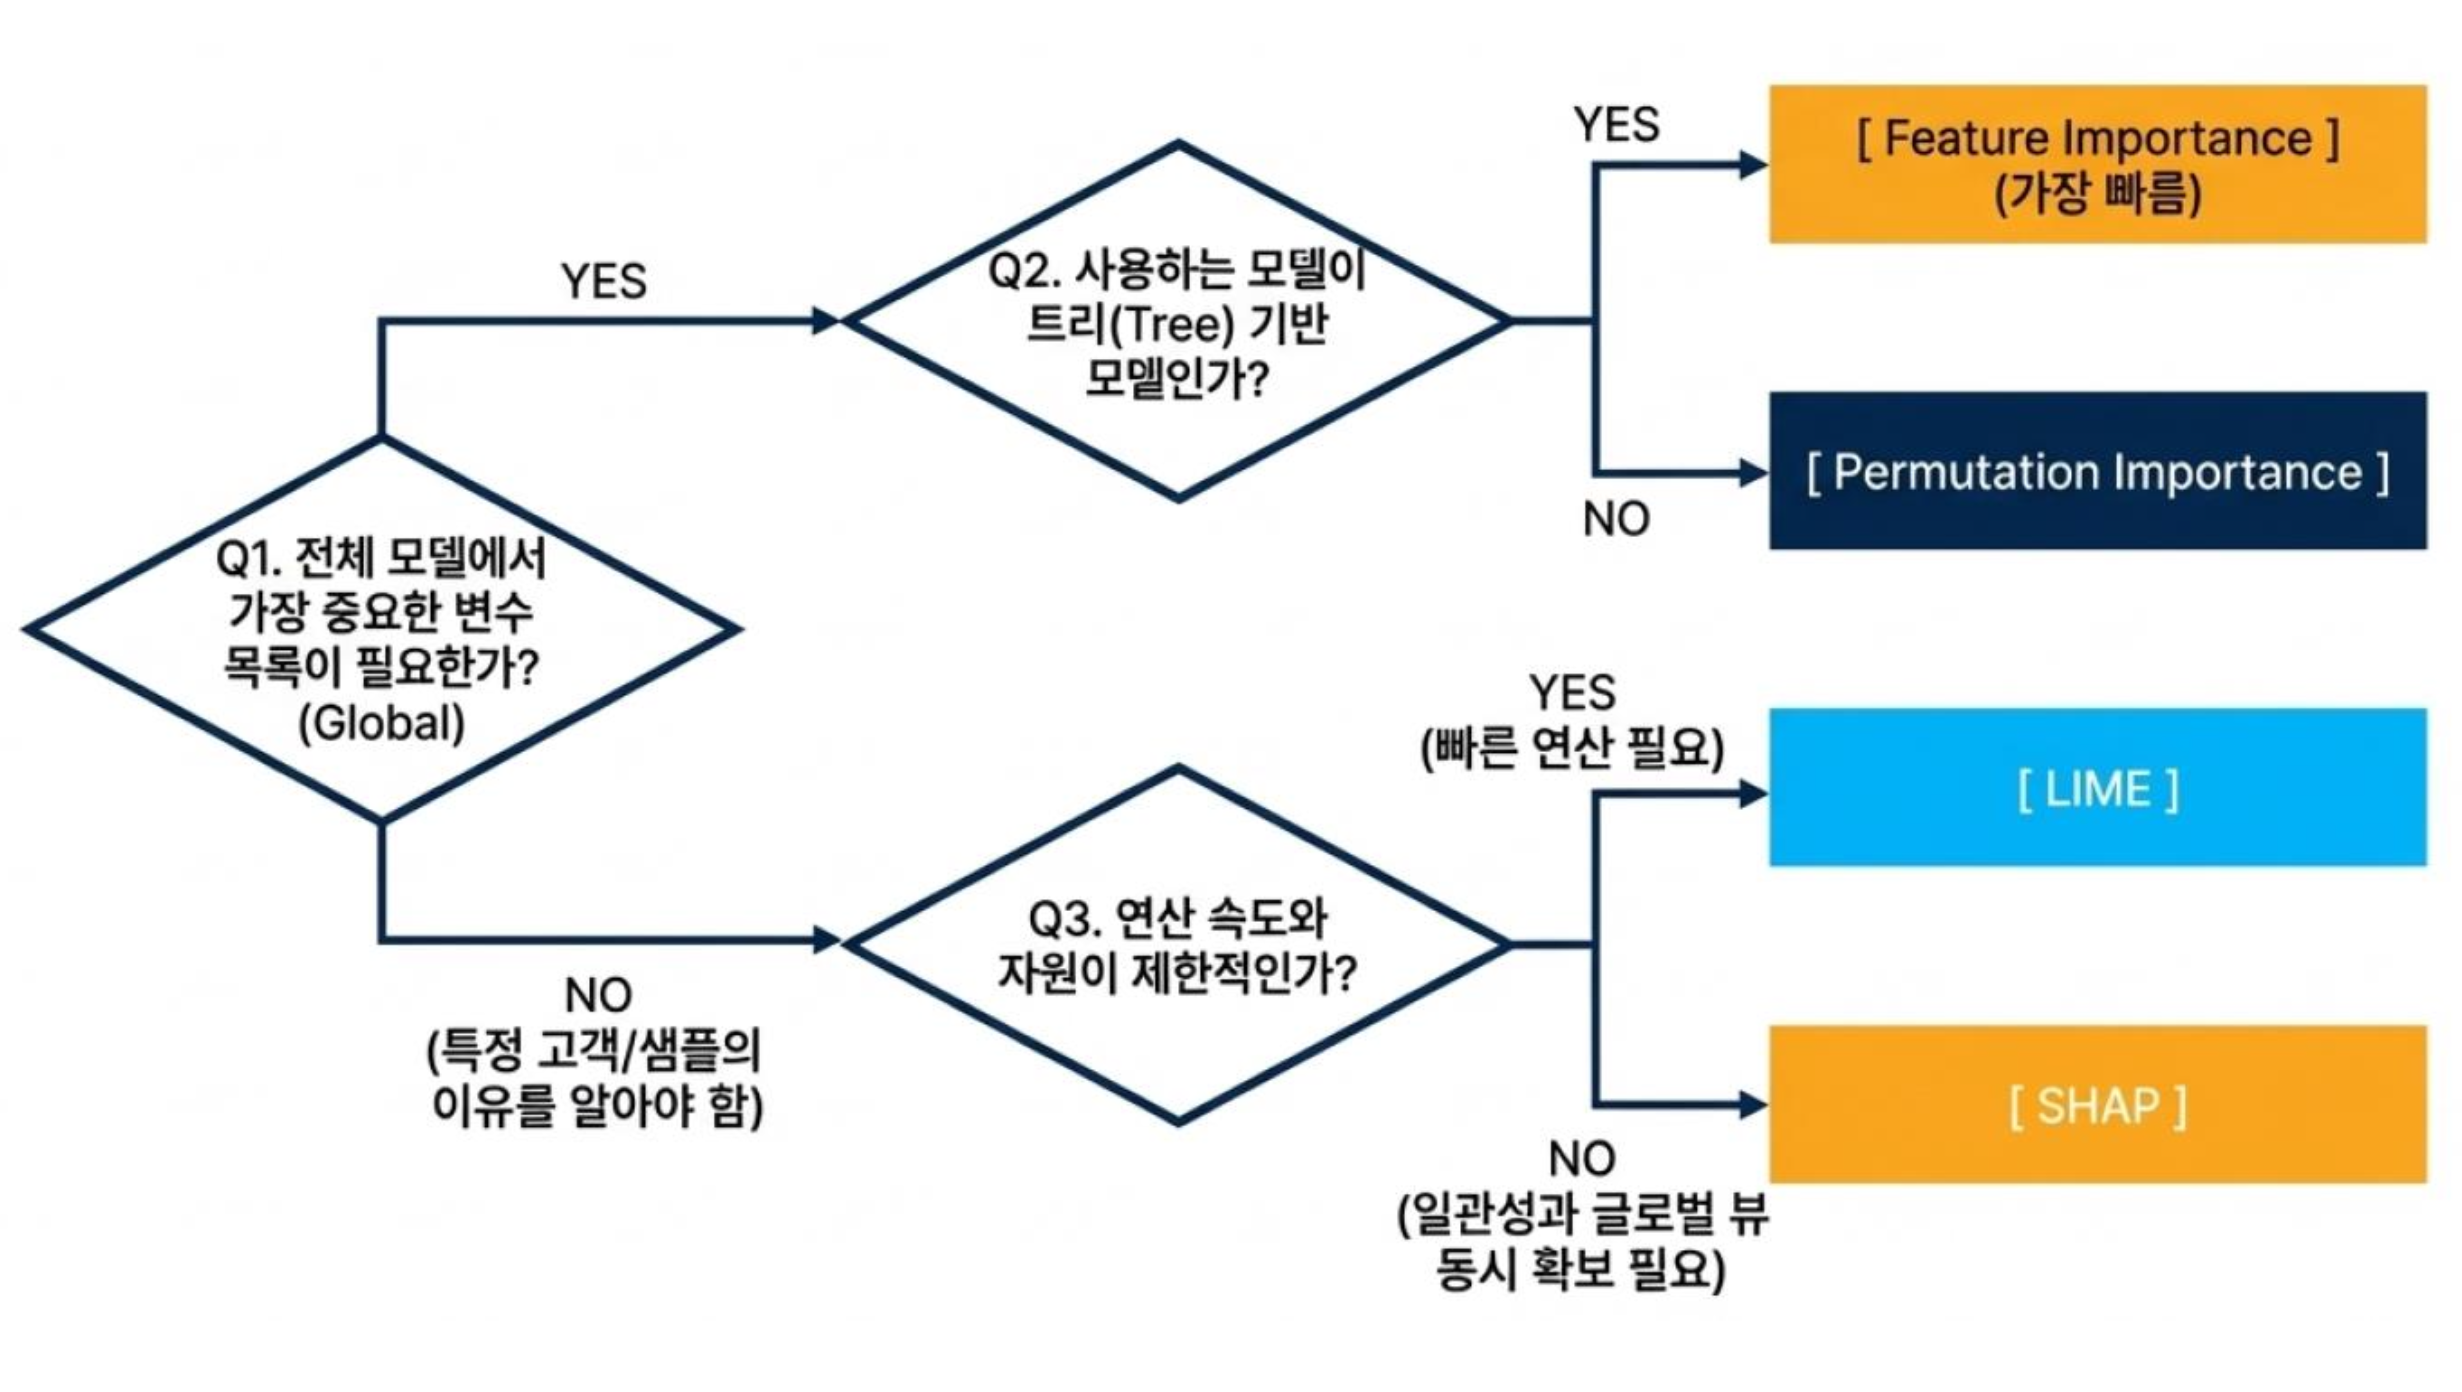

## 분석 파이프라인 (9단계)

1. **환경 설정**: 라이브러리 로드, 드라이브 마운트
2. **데이터 로드**: CSV 파일 읽기, shape 확인
3. **Train/Test 분할**: 7:3 비율, stratify 적용
4. **피처 엔지니어링**: 로그 변환, 비율 변수 생성
5. **기준 모델**: Logistic Regression 학습
6. **Random Forest**: 앙상블 모델 학습
7. **Feature Importance**: 변수 중요도 분석
8. **Permutation Importance**: 성능 기반 중요도
9. **SHAP/LIME**: 모델 해석 및 설명


In [32]:
# 0) 라이브러리 로드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, f1_score
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 200)
print('Ready')

Ready


In [33]:
df = pd.read_csv('week9_hyperparameter_tuning_practice.csv')
df.info()
df.shape
print('-'*30)
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            600 non-null    int64  
 1   income         600 non-null    float64
 2   tenure         600 non-null    int64  
 3   support_calls  600 non-null    int64  
 4   churn          600 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 23.6 KB
------------------------------


,age,income,tenure,support_calls,churn
0,56,4873.0,59,4,1
1,69,4082.0,59,1,0
2,46,875.0,48,4,0
3,32,6284.0,41,1,0
4,60,7006.0,13,1,1


In [34]:

from sklearn.model_selection import train_test_split

x = df.drop(columns=['churn'])
y = df['churn']

x_train, x_test, y_train,  y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

print('[train] class ratio')
print(y_train.value_counts(normalize=True).round(3))
print('\n [test] class ratio')
print(y_test.value_counts(normalize=True).round(3))


[train] class ratio
churn
0    0.75
1    0.25
Name: proportion, dtype: float64

 [test] class ratio
churn
0    0.75
1    0.25
Name: proportion, dtype: float64


---

## 파생변수 설계 및 피처 엔지니어링 전략

### 🎯 핵심 목적 (Why Feature Engineering?)
*   **비선형성 보완:** 소득 등 변수의 왜도를 **로그 변환으로 정규화**하여 비선형 관계를 포착
*   **도메인 신호 강화:** 가입기간 대비 소득/지원 비율로 고객 가치와 불만도를 직접 측정
*   **극단치 완화:** 분모에 +1을 추가하여 0으로 나누는 오류 방지 및 안정성 확보

---

### 🧮 파생변수 설계 가이드 (Feature Creation)

| 파생변수명 | 공식(Formula) | 의미 및 효과 |
| :--- | :--- | :--- |
| **`log_income`** | `np.log1p(income)` | 소득 로그 변환으로 왜도 감소, 극단치 영향 완화 |
| **`income_per_tenure`** | `income / (tenure + 1)` | 가입기간 대비 소득 비율, 고객 가치 및 안정성 지표 |
| **`support_per_tenure`**| `support_calls / (tenure + 1)` | 기간 대비 고객지원 비율, 고객 불만도 측정 |

---

### 💡 핵심 가설 (Hypotheses)

*   🔴 **`support_per_tenure` 높음** $\rightarrow$ **Churn(이탈) 증가**
*   🟢 **`tenure` 길수록** $\rightarrow$ **Churn(이탈) 감소**
*   🟢 **`income_per_tenure` 높음** $\rightarrow$ **안정성 증가**

---

### 📌 핵심 인사이트 (Key Insight)
> **`support_per_tenure`**가 가장 강력한 예측 변수로, 기간 대비 고객지원 비율이 높을수록 고객 이탈 위험이 크게 증가합니다.
> *(변수 수: 4개 $\rightarrow$ 7개로 **+3 파생변수** 확장)*

In [35]:
df_fe = df.copy() 

# 파생변수 1: 소득/기간 (기간이 0이 되는 상황 방지)
df_fe['income_per_tenure'] = df_fe['income'] / (df_fe['tenure'] + 1)

# 파생변수 2: 문의/기간
df_fe['support_per_tenure'] = df_fe['support_calls'] / (df_fe['tenure'] + 1)

# (선택) 로그 변환(분포가 긴 꼬리를 가진 경우 해석/성능에 도움)
df_fe['log_income'] = np.log1p(df_fe['income'].clip(lower=0))

df_fe.head()

,age,income,tenure,support_calls,churn,income_per_tenure,support_per_tenure,log_income
0,56,4873.0,59,4,1,81.216667,0.066667,8.491670
1,69,4082.0,59,1,0,68.033333,0.016667,8.314587
2,46,875.0,48,4,0,17.857143,0.081633,6.775366
3,32,6284.0,41,1,0,149.619048,0.023810,8.745921
4,60,7006.0,13,1,1,500.428571,0.071429,8.854665


In [36]:
# 파생변수 포함 데이터 분할 - x와 y를 분리 / train/test 데이터를 분할
x = df_fe.drop(columns=['churn'])
y = df_fe['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

x_train.shape, x_test.shape

((420, 7), (180, 7))

In [37]:
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

baseline.fit(x_train, y_train)
pred_base = baseline.predict(x_test)

print('Baseline: Logistic Regression (with engineered features)')
print(classification_report(y_test, pred_base, digits=3))
print('F1:', round(float(f1_score(y_test, pred_base)), 4))


Baseline: Logistic Regression (with engineered features)
              precision    recall  f1-score   support

           0      0.920     0.941     0.930       135
           1      0.810     0.756     0.782        45

    accuracy                          0.894       180
   macro avg      0.865     0.848     0.856       180
weighted avg      0.893     0.894     0.893       180

F1: 0.7816


## 📌 베이스라인 모델(Logistic Regression) 핵심 개념

*   ⚙️ **Pipeline의 장점**
    *   여러 단계(스케일링, 모델 학습 등)를 하나로 묶어 일관된 데이터 처리 및 모델 학습을 가능하게 합니다.
*   ⚖️ **StandardScaler 역할**
    *   데이터 표준화(평균=0, 표준편차=1)를 통해 변수 간 스케일 차이로 인한 편향을 해결합니다.
*   🔁 **`max_iter=1000` 의미**
    *   최대 1000번 반복 학습하여 모델이 최적점에 도달(수렴)할 수 있도록 충분한 반복 횟수를 설정합니다.
*   📊 **Accuracy vs F1 Score**
    *   **Accuracy(정확도):** 전체 예측 중 맞춘 비율 (전체적인 성능 파악)
    *   **F1 Score:** 정밀도와 재현율의 조화평균으로, 클래스 불균형 데이터에서 더욱 신뢰할 수 있는 평가지표입니다.

---

## 📈 성능 평가 결과 (기준 모델: Logistic Regression)

| 평가지표 (Metric) | 점수 (Score) |
| :---: | :---: |
| **Accuracy** | **0.894** |
| **F1 Score** | **0.7816** |

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    min_samples_leaf=2
)
rf.fit(x_train, y_train)
pred_rf = rf.predict(x_test)

print('Random Forest')
print(classification_report(y_test, pred_rf, digits=3))
print('F1', round(float(f1_score(y_test, pred_rf)), 4))

Random Forest
              precision    recall  f1-score   support

           0      0.881     0.933     0.906       135
           1      0.757     0.622     0.683        45

    accuracy                          0.856       180
   macro avg      0.819     0.778     0.795       180
weighted avg      0.850     0.856     0.851       180

F1 0.6829


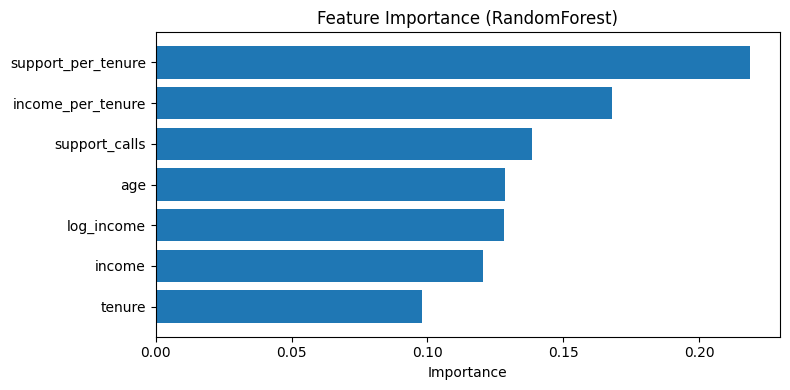

In [40]:
#Feature Importance: 코드와 상위 변수 해석
import matplotlib.pyplot as plt
import pandas as pd

# Feature Importance 계산
imp_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# 중요도 상위 10개 출력
imp_df.head(10)

# Feature Importance 시각화
topn = 10
# 수평 막대 그래프에서 상위 변수가 위로 오도록 순서를 뒤집음(iloc[::-1])
plot_df = imp_df.head(topn).iloc[::-1] 

plt.figure(figsize=(8, 4))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title('Feature Importance (RandomForest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

• Random Forest의 Feature Importance 결과에서 support_per_tenure, income_per_tenure, support_calls가 높은 중요도를 가지며 모델
예측에 가장 큰 영향을 미치는 변수로 나타났다. 반면 tenure는 상대적으로 낮은 중요도를 보여 단독 변수로서의 영향력은
제한적인 것으로 해석된다.

• Feature Importance는 방향(증가/감소)을 알려주지 않고 오직 중요도만 제공

In [ ]:
# 각 변수 10번 shuffle 후 계산
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rf, x_test, y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'feature': x_test.columns,
    'importance': rf.feature_importances_}).sort_values('importance', ascending=False)

perm_df.head(10)

,feature,importance
5,support_per_tenure,0.218770
4,income_per_tenure,0.167711
3,support_calls,0.138376
0,age,0.128539
6,log_income,0.128330
1,income,0.120359
2,tenure,0.097914


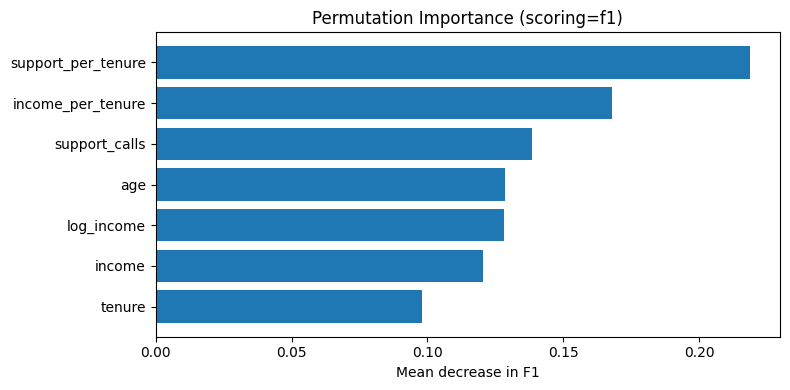

In [47]:
#permutaion 시각화
topn = 10
plot_df = perm_df.head(topn).iloc[::-1] 

# Permutation Importance 시각화
topn = 10
plot_df = perm_df.head(topn).iloc[::-1]

plt.figure(figsize=(8, 4))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title('Permutation Importance (scoring=f1)')
plt.xlabel('Mean decrease in F1')
plt.tight_layout()
plt.show()

---

## 📊 변수 중요도(Importance) 측정 방식 비교

| 구분 | Feature Importance | Permutation Importance |
| :--- | :--- | :--- |
| **계산 기준** | 트리 분기 시 **불순도(impurity) 감소량**을 기준으로 계산 | 변수를 **무작위로 섞었을 때** 발생하는 성능 저하량 측정 |
| **특징** | ✔️ 빠르고 직관적, 모델 내부 기준 | ✔️ 실제 예측 성능 기반, 모델 독립적 |

---

### 💡 해석 포인트

*   **`support_per_tenure`**가 두 방식 모두에서 예측에 가장 큰 영향을 미치는 최상위 변수로 확인됨
*   Feature Importance의 경우, 서로 상관관계가 높은 변수들이 존재하면 **중요도가 분산**되어 나타날 수 있음 (해석 시 주의 필요)
*   Permutation Importance는 실제 모델의 성능 저하를 기반으로 하므로, **실무적인 의사결정**을 내릴 때 더욱 유용한 근거를 제공함

/Users/hong-yuseog/Big-data-application-practice1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


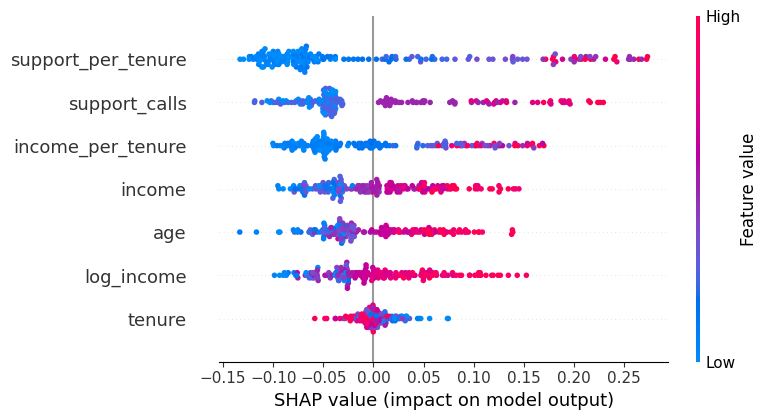

<Figure size 2400x600 with 0 Axes>

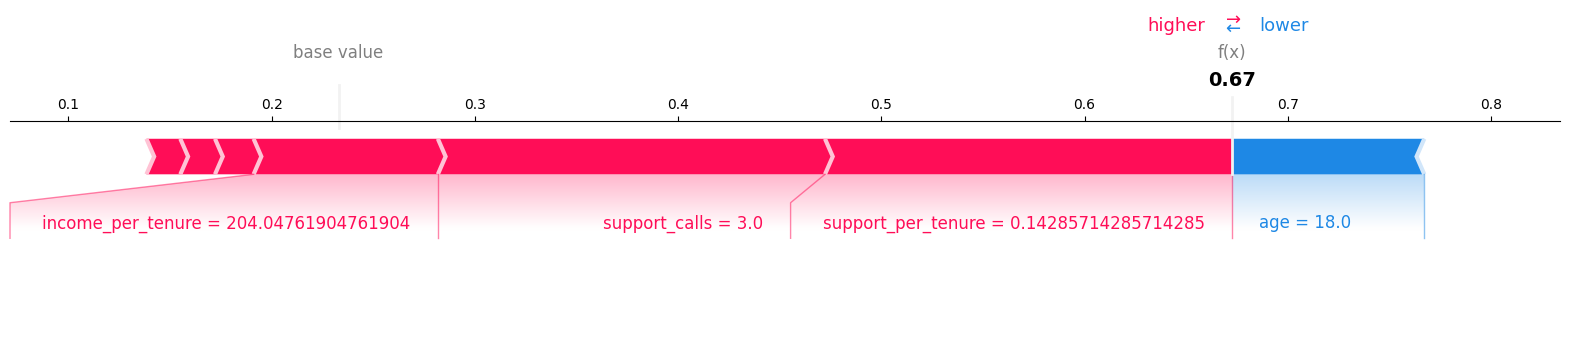

In [49]:
try:
    import shap # SHAP 라이브러리 import
    shap.initjs() # 인터랙티브 시각화(HTML/JS 기반) 초기화

    # x_train을 data 인수로 전달하여 explainer가 특성 공간을 정확히 이해하도록 합니다.
    explainer = shap.TreeExplainer(rf, data=x_train)
    shap_values = explainer.shap_values(x_test)

    # SHAP 값의 형태에 따라 인덱싱 방식을 조정합니다.
    # shap_values가 리스트 형태인 경우 shap_values[1], 3차원 배열인 경우 shap_values[:, :, 1]
    if isinstance(shap_values, list):
        shap_values_for_class_1 = shap_values[1]
        expected_value_for_class_1 = explainer.expected_value[1]
    else:
        # 3D 배열인 경우, 마지막 차원이 클래스를 나타낸다고 가정합니다.
        shap_values_for_class_1 = shap_values[:, :, 1]
        expected_value_for_class_1 = explainer.expected_value[1] # expected_value는 보통 리스트로 반환됨

    # 전역 해석: summary plot
    shap.summary_plot(shap_values_for_class_1, x_test)

    # 국소 해석: 특정 샘플 i
    i = 0
    plt.figure(figsize=(24, 6))  # 그림 크기 확대(겹침 방지)
    # 노트북 환경에 따라 force_plot 출력이 다를 수 있습니다.
    shap.force_plot(
        expected_value_for_class_1,
        shap_values_for_class_1[i],
        x_test.iloc[i],
        matplotlib=True,
        show=True,
        contribution_threshold=0.07
    )

except Exception as e:     # SHAP 실행 실패 시
    print('SHAP 실행 실패(환경/설치 이슈 가능):', e)
    print('필요 시: pip install shap')


## 🔍 SHAP 시각화 해설

### 1. 전역적 변수 중요도 요약 (Summary Plot)
* **중요 변수 순위 파악**
* **`support_per_tenure`**: 값이 클수록 예측값 증가
    * 고객 지원 비율이 높을수록 이탈(Churn) 가능성이 높게 예측됨
* **`tenure`**: 값이 낮을수록 예측값 증가
    * 가입 기간이 짧을수록 이탈 위험이 높으며, 오래된 고객일수록 안정적으로 판단함

### 2. 특정 개별 데이터 예측 설명 (Force Plot)
* SHAP Force Plot은 **Base Value(기본 예측값)** 에서 출발합니다.
* 분석된 특정 샘플의 경우 `income_per_tenure`, `support_calls`, `support_per_tenure` 변수가 예측값을 **증가(+)** 시키는 방향으로 크게 작용했습니다.
* 반면, `age` 변수는 예측값을 **감소(-)** 시키는 방향으로 작용하여, 최종적으로 해당 고객의 **이탈(Churn) 확률이 0.67** 로 형성되었습니다.

---

### 💡 종합 해석
> 이 모델은 **고객의 소득 수준**과 **고객 지원 관련 활동(문의/상담 등)**에 가장 크게 영향을 받습니다. 
> 특히 **고객 지원 활동이 많고 소득 대비 활동 비율이 두드러질수록**, 모델은 해당 고객을 더욱 **'이탈 위험이 높은 상태'**로 판단하는 강력한 경향을 보입니다.

In [50]:
# 선택 2) LIME (대안)

try:
    from lime.lime_tabular import LimeTabularExplainer # 테이블 형태 데이터용 LIME 설명기 클래스(LimeTabularExplainer)를 가져옴

    # LIME 설명기 생성
    explainer = LimeTabularExplainer(
        training_data=np.array(x_train),  # 데이터
        feature_names=x_train.columns.tolist(),  # 변수 이름 리스트
        class_names=['stay', 'churn'],  # 클래스 이름
        mode='classification'  # 분류 문제
    )

    # 해당 고객의 예측 결과를 가장 중요한 변수 6개로 설명
    i = 0
    exp = explainer.explain_instance(
        x_test.iloc[i].values,  # 설명 대상 데이터
        rf.predict_proba,
        num_features=6      # 상위 6개 변수
    )
    exp.show_in_notebook(show_table=True)

except Exception as e:
    print('LIME 실행 실패(환경/설치 이슈 가능):', e)
    print('필요 시: pip install lime')

LIME 실행 실패(환경/설치 이슈 가능): cannot import name 'display' from 'IPython.core.display' (/Users/hong-yuseog/Big-data-application-practice1/.venv/lib/python3.13/site-packages/IPython/core/display.py)
필요 시: pip install lime


/Users/hong-yuseog/Big-data-application-practice1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#위에거 너무 옛날 방식이라 라이브러리 활용하는 방식에 문제가 있음
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML
import numpy as np

# LIME 설명기 생성
explainer = LimeTabularExplainer(
    training_data=np.array(x_train),  # 데이터
    feature_names=x_train.columns.tolist(),  # 변수 이름 리스트
    class_names=['stay', 'churn'],  # 클래스 이름
    mode='classification'  # 분류 문제
)

# 해당 고객의 예측 결과를 가장 중요한 변수 6개로 설명
i = 0
exp = explainer.explain_instance(
    x_test.iloc[i].values,  # 설명 대상 데이터
    rf.predict_proba,
    num_features=6      # 상위 6개 변수
)

# 호환성 에러가 나는 show_in_notebook 대신 우회하는 코드
html_data = exp.as_html(show_table=True)
display(HTML(html_data))


/Users/hong-yuseog/Big-data-application-practice1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


---
## 🔍 LIME 시각화 해설

### 1. 전체 예측 결과
* **이 고객은 이탈(Churn) 가능성이 높은 고객으로 예측됨**
  * `Stay`: 0.33 
  * `Churn`: 0.67

### 2. LIME 그래프 구조 이해
* 🟦 **파란색** $\rightarrow$ Stay 방향 (이탈 예측값 감소)
* 🟧 **주황색** $\rightarrow$ Churn 방향 (이탈 예측값 증가)

### 3. Churn(이탈)을 증가시키는 요인
* **`support_per_tenure ≈ 0.14`** / 영향력: **+0.27** (가장 큼)
* 고객 지원 비율이 높아 문제/불만이 많을 가능성이 크며, 이는 이탈 위험 증가로 이어짐.

### 4. Churn을 낮추는 요인
* **`age ≤ 32`** / 영향력: **-0.08**

### 5. 종합 결론
* 이 고객은 상담 횟수와 지원 비율이 높은 것이 가장 큰 이탈 요인이며, 상대적으로 젊은 나이는 이탈 가능성을 일부 낮추지만 **전체적으로는 이탈 요인이 더 강하게 작용**합니다.
* LIME 분석 결과, `support_per_tenure`와 `support_calls`가 가장 큰 양(+)의 영향을 미쳐 해당 고객의 Churn 확률을 증가시키는 주요 요인으로 나타났습니다. 
* 반면, `age`는 Churn 확률을 감소시키는 요인으로 작용하지만, 전체적으로는 이탈을 유도하는 변수들의 영향이 더 크게 작용하여 최종적으로 Churn으로 예측되었습니다.
* **⚠️ 주의:** LIME에서 **"+"**는 변수 자체가 긍정적이라는 뜻이 아니라, **"해당 조건(구간)"이 Churn 방향으로 작용한다는 의미**입니다.